# 🚗 Car Price Prediction Using Machine Learning

## 🎯 Objective

The objective of this project is to build a machine learning model capable of predicting the selling price of used cars based on various features such as:
- car brand,
- fuel type,
- transmission,
- mileage,
- engine capacity,
- and ownership details.

This project demonstrates:
- data preprocessing,
- exploratory data analysis,
- feature engineering,
- regression modeling,
- and model evaluation.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [31]:
df = pd.read_csv("../data/car data.csv")

In [32]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [33]:
df.shape

(301, 9)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [35]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [36]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(2)

In [38]:
df.drop_duplicates(inplace=True)

In [39]:
df.drop('Car_Name', axis=1, inplace=True)

In [40]:
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [41]:
df['Car_Age'] = 2026 - df['Year']

In [42]:
df.drop('Year', axis=1, inplace=True)

In [43]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [44]:
encoder = LabelEncoder()

In [45]:
categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

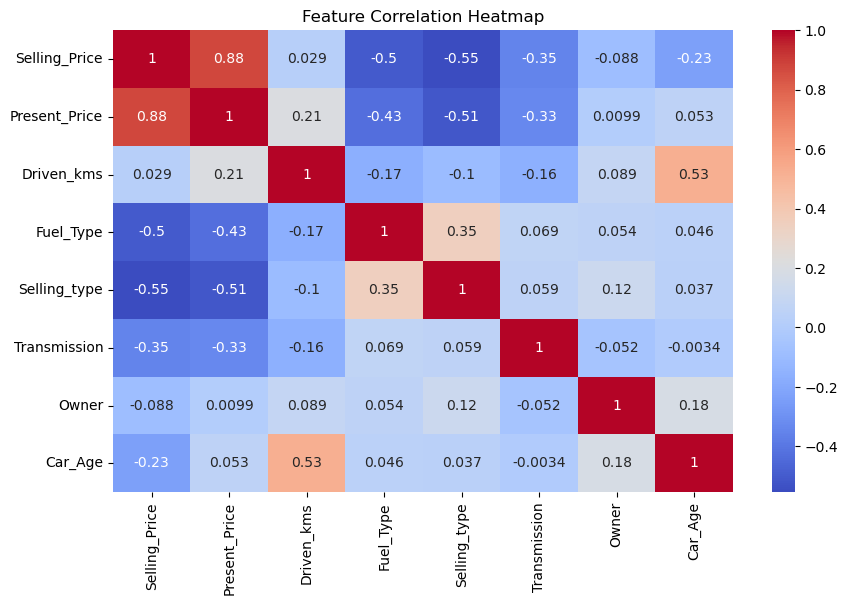

In [46]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [47]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [50]:
y_pred_lr = lr_model.predict(X_test)

In [51]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

MAE: 1.5408119549693529
MSE: 6.675444100492248
R2 Score: 0.7409934356413544


- MAE=n1​∑∣yi​−y^​i​∣ means:on average, model predictions are off by:~1.54 lakhs
- MSE=n1​∑(yi​−y^​i​)2 means:some predictions have larger errors,squared penalty increases impact of big mistakes.
- R2=1−SStot/SSres​​ model explains ~74% of the variation in car prices

In [52]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, random_state=42)

In [53]:
y_pred_rf = rf_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 1.3788584130049297
MSE: 10.28578147480102
R2 Score: 0.6009127061171009


# 📊 Model Comparison

In [54]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf)
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,MAE,MSE,R2 Score
0,Linear Regression,1.540812,6.675444,0.740993
1,Random Forest,1.378858,10.285781,0.600913


## 📌 Model Performance Analysis

Although Random Forest Regressor is a more advanced ensemble model, Linear Regression achieved better generalization performance on this dataset.

Possible reasons include:
- relatively small dataset size,
- strong linear relationships between features and target,
- and reduced overfitting in the simpler Linear Regression model.

This demonstrates that more complex models do not always guarantee better performance.

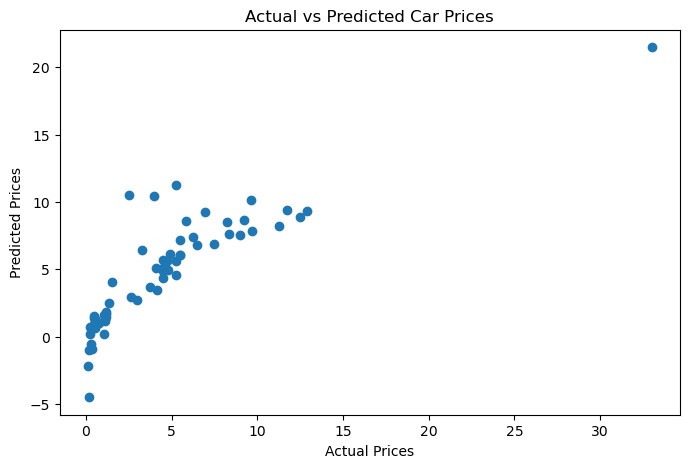

In [55]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Car Prices")

plt.show()

# 📌 Key Insights

- Present price of the car strongly influences selling price.
- Older cars generally have lower resale values.
- Linear Regression performed better than Random Forest on this dataset.
- Simpler models can sometimes generalize better on smaller datasets.

# ✅ Conclusion

This project successfully built a machine learning model for predicting used car prices.

The project demonstrated:
- data preprocessing,
- feature engineering,
- categorical encoding,
- regression modeling,
- and model evaluation.

Among the tested models, Linear Regression achieved the best overall performance for this dataset.